### `Vocabulary Diversity Indices (TTR)`

Type-Token Ratio is used to estimate the lexical diversity of a text.
TTR = Number of unique words/ total number of words
- A higher TTR means greater lexical diversity.
- A lower TTR means more repetition of words.

Type-Token Ratio (TTR) is known to be biased by text length (as the length increases, TTR tends to decrease due to repeated words, even if the vocabulary is diverse).

To address this, we we use *MATTR (Moving-Average Type-Token Ratio)*. Instead of calculating TTR over the entire text, MATTR measures lexical diversity in local segments. It works by sliding a fixed-size window (e.g., 100 words) across the text, one word at a time. At each step, it calculates the TTR for that window. The final score is the average of all those micro TTRs.


In [18]:
import math
import regex as re
import unicodedata
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r"[^\p{L}\s'-]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_text(text):
    if isinstance(text, pd.Series) or isinstance(text, list):
        tokens = []
        for row in text:
            row = preprocess(row)
            tokens.extend(re.findall(r"\p{L}+(?:['-]\p{L}+)*", row))
        return tokens
    elif isinstance(text, str):
        text = preprocess(text)
        return re.findall(r"\p{L}+(?:['-]\p{L}+)*", text)
    else:
        return []

In [20]:
def calculate_ttr(text):
    tokens = tokenize_text(text)
    if not tokens:
        return 0.0
    unique_tokens = set(tokens)
    return len(unique_tokens) / len(tokens) 

In [21]:
def calculate_mattr(text, window_size=100):
    tokens = tokenize_text(text)
    if not tokens:
        return 0.0

    if len(tokens) < window_size:
        return calculate_ttr(tokens)

    def sliding_window(tokens, win_size):
        return [tokens[i:i + win_size] for i in range(len(tokens) - win_size + 1)]

    windows = sliding_window(tokens, window_size)
    scores = [len(set(window)) / window_size for window in windows]

    return sum(scores) / len(scores)
 

In [22]:
rf_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/YANKARI.csv")["text"][:1]

wura_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/wura_yor.csv")["content"]

noisy_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/yor_dataset.csv")["prompt"][:50]

In [23]:
scores = wura_text.apply(calculate_mattr)

for index, score in enumerate(scores):
    print(f"Document {index + 1}: {score:.4f}")

Document 1: 0.7058
Document 2: 0.6062
Document 3: 0.6633
Document 4: 0.7737
Document 5: 0.6380
Document 6: 0.6453
Document 7: 0.6425
Document 8: 0.6688
Document 9: 0.6632
Document 10: 0.6038
Document 11: 0.6717
Document 12: 0.6634
Document 13: 0.7168
Document 14: 0.6740
Document 15: 0.7553
Document 16: 0.7195
Document 17: 0.6751
Document 18: 0.6499
Document 19: 0.5893
Document 20: 0.6448
Document 21: 0.7289
Document 22: 0.6375
Document 23: 0.6202
Document 24: 0.6609
Document 25: 0.6405
Document 26: 0.6705
Document 27: 0.6307
Document 28: 0.7143
Document 29: 0.6194
Document 30: 0.6500
Document 31: 0.6087
Document 32: 0.6042
Document 33: 0.6835
Document 34: 0.6414
Document 35: 0.6814
Document 36: 0.6813
Document 37: 0.6691
Document 38: 0.6467
Document 39: 0.6636
Document 40: 0.6947
Document 41: 0.6956
Document 42: 0.6127
Document 43: 0.5866
Document 44: 0.7647
Document 45: 0.6182
Document 46: 0.6877
Document 47: 0.6744
Document 48: 0.6420
Document 49: 0.6217
Document 50: 0.7582
Document 

In [ ]:
for index, score in enumerate(scores):
    if score < 0.5:
        print(f"Document {index + 1} has a low MATTR score: {score:.4f}")
    elif score < 0.75:
        print(f"Document {index + 1} has a moderate MATTR score: {score:.4f}")
    else:
        print(f"Document {index + 1} has a high MATTR score: {score:.4f}")


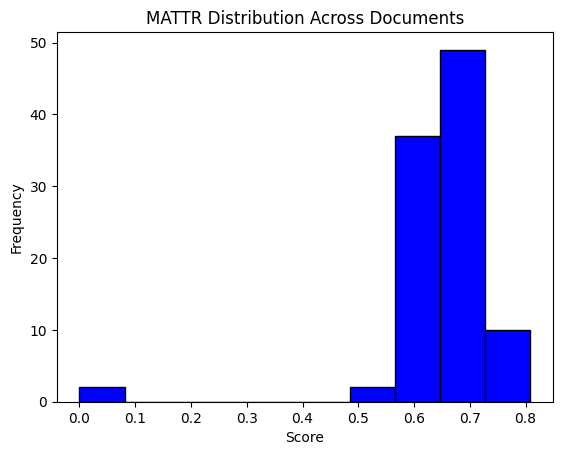

In [24]:
plt.hist(scores, color='blue', edgecolor='black')
plt.title('MATTR Distribution Across Documents')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

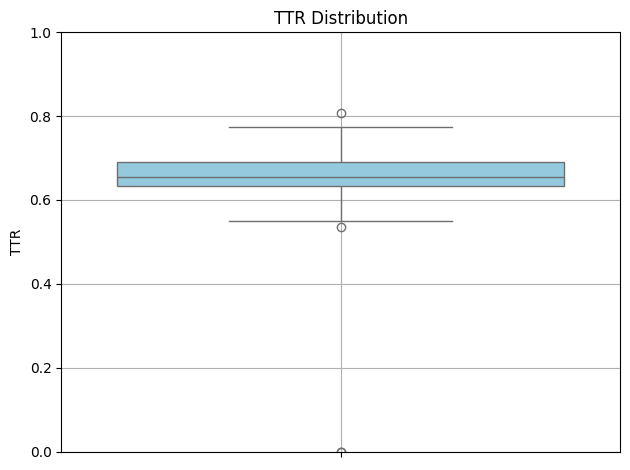

In [25]:
import seaborn as sns

sns.boxplot(data=scores, color='skyblue')
plt.title('TTR Distribution')
plt.ylabel('TTR')
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
scores_2 = noisy_text.apply(calculate_mattr)

for index, score in enumerate(scores):
    print(f"Document {index + 1}: {score:.4f}")

Document 1: 0.7058
Document 2: 0.6062
Document 3: 0.6633
Document 4: 0.7737
Document 5: 0.6380
Document 6: 0.6453
Document 7: 0.6425
Document 8: 0.6688
Document 9: 0.6632
Document 10: 0.6038
Document 11: 0.6717
Document 12: 0.6634
Document 13: 0.7168
Document 14: 0.6740
Document 15: 0.7553
Document 16: 0.7195
Document 17: 0.6751
Document 18: 0.6499
Document 19: 0.5893
Document 20: 0.6448
Document 21: 0.7289
Document 22: 0.6375
Document 23: 0.6202
Document 24: 0.6609
Document 25: 0.6405
Document 26: 0.6705
Document 27: 0.6307
Document 28: 0.7143
Document 29: 0.6194
Document 30: 0.6500
Document 31: 0.6087
Document 32: 0.6042
Document 33: 0.6835
Document 34: 0.6414
Document 35: 0.6814
Document 36: 0.6813
Document 37: 0.6691
Document 38: 0.6467
Document 39: 0.6636
Document 40: 0.6947
Document 41: 0.6956
Document 42: 0.6127
Document 43: 0.5866
Document 44: 0.7647
Document 45: 0.6182
Document 46: 0.6877
Document 47: 0.6744
Document 48: 0.6420
Document 49: 0.6217
Document 50: 0.7582
Document 

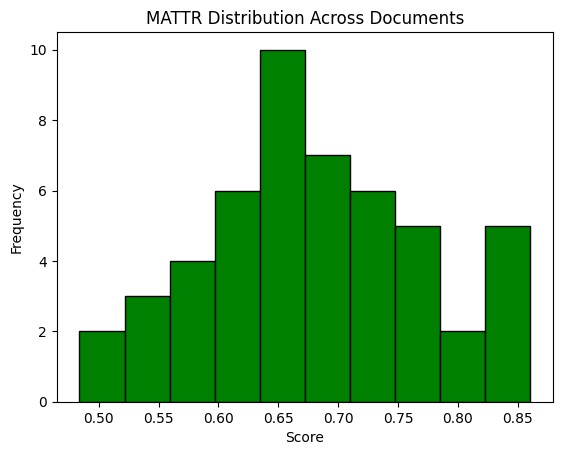

In [27]:
plt.hist(scores_2, color='green', edgecolor='black')
plt.title('MATTR Distribution Across Documents')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

#### Note

**Limitation** 

TTR and MATTR are used here as part of the **naturalness** metrics because they measure how diverse the vocabulary in a text is. But they don’t check whether the words themselves are valid or meaningful. So, if a text is noisy, full of typos or random tokens, it can still get a high score just because it looks “diverse.”

This came up when testing on the **mC4-Yoruba** corpus, which has some inconsistent or unclean data. In those cases, a high TTR score doesn’t really mean the text is natural, just that it contains lots of different words, even if they’re off.

This could affect the **final naturalness score** when all the metrics are combined. To avoid TTR having too much influence, it might be better to **cap its contribution** or give it less weight compared to something like n-gram log-probability.

`Bucketing`

We want to caclculate TTR scores within buckets in order to 
- identify the typical TTR in various text lengths
- spot outliers.

In [16]:
def mattr_bucket(tokenizer, docs, window_size):

# Bucket ranges for different lengths of documents
    bucket_ranges = [
        (0, 100),
        (101, 300),
        (301, 700),
        (701, 1500),
        (1501, float('inf'))
    ]


    def get_bucket_range(length):
        for low, high in bucket_ranges:
            if low <= length <= high:
                return (low, high)
        return (float('inf'), float('inf'))

#To group the scores by document length
    grouped_scores = {}

    for doc in docs:
        tokens = tokenizer(doc)
        length = len(tokens)
        score = calculate_mattr(tokens, window_size)
        label = get_bucket_range(length)

        if label not in grouped_scores:
            grouped_scores[label] = []
        grouped_scores[label].append(score)

    return dict(grouped_scores)


In [17]:
wura_scores = mattr_bucket(tokenize_text, wura_text, window_size=100)

for bucket, scores in sorted(wura_scores.items(), key=lambda x: x[0][0]):
    print(f"{bucket} = {scores}")


(0, 100) = [0.6632653061224489, 0.7553191489361702, 0.7195121951219512, 0.6704545454545454, 0.7142857142857143, 0.6947368421052632, 0.6744186046511628, 0.7582417582417582, 0.7551020408163265, 0.8085106382978723, 0.7, 0.6947368421052632, 0.6463414634146342, 0.0, 0.647887323943662, 0.75, 0.0, 0.5967741935483871, 0.7215189873417721, 0.75, 0.6933333333333334]
(101, 300) = [0.7057547169811322, 0.6061764705882351, 0.773655913978495, 0.6717391304347824, 0.6634482758620691, 0.7168000000000002, 0.6739999999999999, 0.6751401869158874, 0.649880952380952, 0.5892907801418446, 0.6447863247863245, 0.7288888888888889, 0.6375, 0.6202040816326533, 0.6608823529411766, 0.6405309734513278, 0.6306521739130433, 0.6194444444444444, 0.65, 0.6086666666666667, 0.604181818181818, 0.6834558823529416, 0.6413725490196076, 0.6814285714285715, 0.6812707182320449, 0.6690909090909093, 0.6466842105263163, 0.6635714285714286, 0.6955652173913051, 0.6126851851851853, 0.586551724137931, 0.7647457627118642, 0.6181538461538465